<a href="https://colab.research.google.com/github/lvjr3383/AI_Safety/blob/main/ml-basics/Part6_Neural_Networks_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks From Scratch
### Part 6 of the ML Basics Series

You know the loop by now:

```text
Data → Model → Prediction → Loss → Optimization → Evaluation → Generalization
```

Part 5 used sklearn's `.fit()`, which hides the model. Part 4 used PyTorch's autograd, which hides the derivatives.

This one hides nothing. We write the forward pass, the loss, and backprop ourselves, in NumPy.

By the end of this notebook:

- a neuron is just `w · x + b` plus a bend
- a layer is a stack of those
- an MLP is a stack of layers
- you'll have written a forward pass, a loss, and backprop by hand
- you'll have trained a small network on a small problem

We grow one network — 2 features → 8 hidden neurons → 1 output — until it draws a curve around two classes.

No CNNs, no Adam, no MNIST. Those are Part 7.

---
## 1. Setup

Just NumPy and matplotlib here. No sklearn, no autograd — we're building the engine ourselves this time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fixing the seed so the random numbers repeat the same way every time you run this
np.random.seed(42)
print("Random seed fixed at 42.")

Random seed fixed at 42.


The seed keeps the random numbers the same across runs. Re-run a cell and nothing shifts on you.

---
## 2. The core idea

A linear model, from Parts 2 and 5:

\[
\hat{y} = wx + b
\]

That only draws a straight cut. A neural network adds two things on top of it: a bend (a nonlinearity) right after the linear step, and a stack of those pieces, one after another.

Worth sitting with before any code: if you stacked 10 layers of `Wx + b` with no bend anywhere, would that be more powerful than one layer? Hold that thought — we'll test it directly, on real data, later in this notebook.

---
## 3. A single neuron

One neuron does two things:

\[
z = w_1 x_1 + w_2 x_2 + b
\]

\[
a = f(z)
\]

`z` is the raw score, same idea as linear regression. `f` is the bend. `a` is what the next layer sees.

Shape discipline from Part 2 still applies: `x` is a vector, `w` is a vector of the same length, `b` is a scalar. The cell below computes `z` only — no bend yet.

In [2]:
x = np.array([1.0, 2.0])   # two input features
w = np.array([0.5, -0.3])  # one weight per feature
b = 0.1                    # bias

z = np.dot(w, x) + b       # weighted sum plus bias — the "raw score"
print("x =", x)
print("w =", w)
print("b =", b)
print("z = w·x + b =", z)

x = [1. 2.]
w = [ 0.5 -0.3]
b = 0.1
z = w·x + b = 2.7755575615628914e-17


`z` comes out to `0.0` (0.5×1 + -0.3×2 + 0.1). Still just a number on a straight line — the next cell bends it.

ReLU: keep the positive part, zero out the rest. It's one line of code, and it's what most modern networks actually use, so it's where we start.

In [3]:
def relu(z):
    # Keep positive numbers as-is, turn negative numbers into 0
    return np.maximum(0, z)

a = relu(z)
print("a = relu(z) =", a)

a = relu(z) = 2.7755575615628914e-17


`z` was `0.0`, so ReLU leaves it at `0.0` — it only kills negatives.

**Try it.** Change `w` above so `z` comes out negative, then re-run both cells. `a` should print `0.0`.

---
## 4. Why the bend matters

Same line, two ways: as-is, and passed through ReLU. Plotting both side by side to see the hinge with our own eyes before moving on.

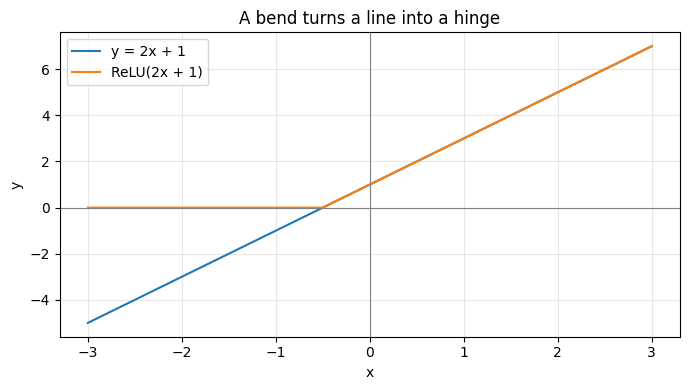

In [4]:
xs = np.linspace(-3, 3, 200)      # 200 x-values from -3 to 3
linear = 2 * xs + 1                # the plain line
bent = relu(linear)                # same line, passed through ReLU

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, linear, label="y = 2x + 1")
ax.plot(xs, bent, label="ReLU(2x + 1)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("A bend turns a line into a hinge")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ReLU shuts off wherever `2x + 1 ≤ 0`, which is `x ≤ -0.5`. Left of that point the line reads a flat `0`. Right of it, it's the original line, untouched.

---
## 5. A layer is several neurons

One neuron gives you one number out. A layer is several neurons looking at the same input at once.

Matrix form from Part 2:

\[
Z = XW + b
\]

Shapes: `X` is `(n_examples, n_features)`, `W` is `(n_features, n_neurons)`, `b` is `(n_neurons,)`, and `Z` comes out `(n_examples, n_neurons)`.

Small batch below: 3 examples, 2 features, 4 neurons.

In [5]:
X_tiny = np.array([
    [0.2, -0.4],
    [1.0,  0.5],
    [-0.3, 0.8],
])  # 3 examples, 2 features each

W_layer = np.array([
    [ 0.4, -0.2, 0.1,  0.3],
    [-0.5,  0.6, 0.0, -0.1],
])  # 2 features -> 4 neurons

b_layer = np.array([0.05, -0.1, 0.2, 0.0])  # one bias per neuron

Z = X_tiny @ W_layer + b_layer   # same math as one neuron, done for a whole layer at once
print("X shape:", X_tiny.shape)
print("W shape:", W_layer.shape)
print("b shape:", b_layer.shape)
print("Z shape:", Z.shape)
print("Z =\n", np.round(Z, 3))

X shape: (3, 2)
W shape: (2, 4)
b shape: (4,)
Z shape: (3, 4)
Z =
 [[ 0.33 -0.38  0.22  0.1 ]
 [ 0.2  -0.    0.3   0.25]
 [-0.47  0.44  0.17 -0.17]]


`(3, 2) @ (2, 4) + (4,)` gives `(3, 4)` — three examples, four raw scores each. Still no bend applied.

In [6]:
A = relu(Z)   # same bend as before, applied to the whole layer at once
print("A = relu(Z), shape:", A.shape)
print("A =\n", np.round(A, 3))

A = relu(Z), shape: (3, 4)
A =
 [[0.33 0.   0.22 0.1 ]
 [0.2  0.   0.3  0.25]
 [0.   0.44 0.17 0.  ]]


Same three examples, four opinions about each one, now bent. Every `0.0` in `A` is a neuron that turned off for that example — for instance, neuron 2 in row 1 was negative before the bend and reads `0.0` after it.

**Try it.** For 8 neurons instead of 4, which shapes change? `W` becomes `(2, 8)`, `b` becomes `(8,)`, and `Z`/`A` both become `(3, 8)`.

---
## 6. Stack layers: an MLP

An MLP is layers in a chain. Here's the architecture we'll use for the rest of this notebook:

- input: 2 features
- hidden: 8 neurons + ReLU
- output: 1 number, then a sigmoid to turn it into a probability

2 → 8 → 1: small enough to print, big enough to be more than one neuron. The cell below initializes the weights randomly — random weights are a terrible model, but they're the same kind of numbers `.fit()` was finding for you all along.

In [7]:
def init_params(n_in=2, n_hidden=8, n_out=1, seed=42):
    rng = np.random.default_rng(seed)
    # Small random numbers — big ones would push the sigmoid into a flat, useless zone
    W1 = rng.normal(0, 0.5, size=(n_in, n_hidden))   # input -> hidden weights
    b1 = np.zeros(n_hidden)                          # hidden biases start at 0
    W2 = rng.normal(0, 0.5, size=(n_hidden, n_out))  # hidden -> output weights
    b2 = np.zeros(n_out)                             # output bias starts at 0
    return W1, b1, W2, b2


W1, b1, W2, b2 = init_params()
print("W1", W1.shape, "b1", b1.shape)
print("W2", W2.shape, "b2", b2.shape)
print("W1 (first row):", np.round(W1[0], 3))
print("W2 (first four):", np.round(W2[:4, 0], 3))

W1 (2, 8) b1 (8,)
W2 (8, 1) b2 (1,)
W1 (first row): [ 0.152 -0.52   0.375  0.47  -0.976 -0.651  0.064 -0.158]
W2 (first four): [ 0.184 -0.479  0.439 -0.025]


`(2, 8)` then `(8, 1)` — that's the whole model. The numbers are random right now and don't mean anything yet. Training is what gives them meaning.

---
## 7. Forward pass

Data goes in, a prediction comes out — four lines:

\[
\begin{aligned}
Z_1 &= X W_1 + b_1 \\
A_1 &= \mathrm{ReLU}(Z_1) \\
Z_2 &= A_1 W_2 + b_2 \\
A_2 &= \sigma(Z_2)
\end{aligned}
\]

`A2` is a probability for class 1. Nothing's trained yet, so it'll still produce numbers — just not useful ones.

In [8]:
def sigmoid(z):
    z = np.clip(z, -50, 50)   # stops overflow errors for very large or very small z
    return 1.0 / (1.0 + np.exp(-z))


def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1     # hidden layer, raw scores
    A1 = relu(Z1)        # hidden layer, bent
    Z2 = A1 @ W2 + b2    # output layer, raw score
    A2 = sigmoid(Z2)     # output layer, turned into a 0-1 probability
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}  # save everything — backprop needs it later
    return A2, cache


X_demo = np.array([[0.2, -0.4], [1.0, 0.5], [-0.3, 0.8]])
A2, cache = forward(X_demo, W1, b1, W2, b2)
print("X  ", X_demo.shape)
print("Z1 ", cache["Z1"].shape)
print("A1 ", cache["A1"].shape)
print("Z2 ", cache["Z2"].shape)
print("A2 ", A2.shape)
print("A2 (probabilities) =\n", np.round(A2, 3))

X   (3, 2)
Z1  (3, 8)
A1  (3, 8)
Z2  (3, 1)
A2  (3, 1)
A2 (probabilities) =
 [[0.491]
 [0.595]
 [0.488]]


Shapes go `(3, 2) → (3, 8) → (3, 1)`. The three probabilities print as roughly `0.491`, `0.595`, `0.488` — all close to a coin flip, which is exactly what an untrained network should look like.

**Try it.** Add a third feature row to `X_demo` and re-run. `Z1` and `A1` should both become `(4, 8)`.

---
## 8. How wrong is a prediction?

We need a way to score how wrong a probability is. Here's the test: if the true label is 1 and we predicted `0.01`, that should cost a lot. If we predicted `0.5` — basically "no idea" — that should cost less than being confidently wrong, but still something.

The cell below runs that test on four made-up predictions before we name the rule.

In [9]:
def bce(a, y):
    a = np.clip(a, 1e-7, 1.0 - 1e-7)   # avoid log(0), which is undefined
    return float(-np.mean(y * np.log(a) + (1.0 - y) * np.log(1.0 - a)))


fake_a = np.array([[0.99], [0.01], [0.50], [0.80]])  # made-up predictions
fake_y = np.array([[1.0],  [1.0],  [0.0],  [0.0]])   # made-up true labels
print("preds  ", fake_a.ravel())
print("labels ", fake_y.ravel())
print("loss   ", round(bce(fake_a, fake_y), 3))

preds   [0.99 0.01 0.5  0.8 ]
labels  [1. 1. 0. 0.]
loss    1.729


Average loss comes out to `1.729`. Row 1 (label `1`, prediction `0.01`) is the expensive one — confidently wrong. Row 0 (label `1`, prediction `0.99`) is nearly free. Row 2, predicting `0.5` with no real opinion, costs something too, just less than being wrong with confidence.

This scoring rule has a name: binary cross-entropy.

\[
L = -\frac{1}{n}\sum_i \Big[ y_i \log a_i + (1-y_i)\log(1-a_i) \Big]
\]

The function above computes exactly that average, over however many rows you give it.

Now the same measurement, but on the untrained network's own predictions from Section 7 instead of made-up numbers.

In [10]:
y_demo = np.array([[1.0], [0.0], [1.0]])  # true labels for X_demo
print("untrained A2 =", np.round(A2.ravel(), 3))
print("labels       =", y_demo.ravel())
print("untrained loss =", round(bce(A2, y_demo), 3))

untrained A2 = [0.491 0.595 0.488]
labels       = [1. 0. 1.]
untrained loss = 0.777


Loss comes out to about `0.777` — close to `-log(0.5) ≈ 0.693`, which makes sense: an untrained network with predictions near `0.5` is basically guessing.

**Try it.** If every prediction were exactly `0.5`, would the loss be zero? No — it'd sit right at `0.693`. "I have no idea" for every example still costs something.

---
## 9. Backprop is blame, assigned backward

Training question: which weights should move, and which way? Calculus already answered this in Part 3 — follow the gradient. Backprop is the chain rule applied to the forward pass we just wrote, sending a "how much were you at fault?" signal backward through the network.

```text
input X  →  hidden A1  →  output A2  →  loss L
                ↑              ↑
              W1, b1         W2, b2
```

Before writing that for the full network, a one-parameter warmup — the same "step against the gradient" loop from Part 5, on a single number.

In [11]:
# One parameter, one target: pred = w * 2, and we want pred to hit 10.
# loss = (pred - 10)^2

w_toy = 0.0
xs_toy, y_toy = 2.0, 10.0
print("start w =", w_toy)
for step in range(8):
    pred = w_toy * xs_toy
    loss = (pred - y_toy) ** 2
    dloss_dw = 2 * (pred - y_toy) * xs_toy   # the gradient — how loss changes as w changes
    w_toy = w_toy - 0.05 * dloss_dw          # step against that gradient
    print(f"step {step+1}: pred={pred:6.2f}  loss={loss:7.2f}  w={w_toy:.3f}")

start w = 0.0
step 1: pred=  0.00  loss= 100.00  w=2.000
step 2: pred=  4.00  loss=  36.00  w=3.200
step 3: pred=  6.40  loss=  12.96  w=3.920
step 4: pred=  7.84  loss=   4.67  w=4.352
step 5: pred=  8.70  loss=   1.68  w=4.611
step 6: pred=  9.22  loss=   0.60  w=4.767
step 7: pred=  9.53  loss=   0.22  w=4.860
step 8: pred=  9.72  loss=   0.08  w=4.916


`w` climbs toward `5` over the 8 steps, since `5 × 2 = 10`. One number, one blame signal, one step, repeated. A full network runs the same loop with more boxes — the next few cells write that blame signal for our specific 2→8→1 net.

---
## 10. Backprop, for this network only

Not a reusable layer class, not a general engine — just the gradients for this exact architecture. The comments spell out what each line means in plain English.

In [12]:
def backward(cache, y, W2, use_relu=True):
    """Work out the blame for this 2-8-1 net. y has shape (n, 1)."""
    X, Z1, A1, A2 = cache["X"], cache["Z1"], cache["A1"], cache["A2"]
    n = X.shape[0]

    # How wrong the output score was. For sigmoid + BCE together, this simplifies to (prediction - label).
    dZ2 = (A2 - y) / n
    # How much each hidden neuron's output (A1) contributed to that error.
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ W2.T
    # ReLU rule: a neuron that was off (Z1 <= 0) gets zero blame — it had no effect on the output.
    dZ1 = dA1 * (Z1 > 0) if use_relu else dA1
    # How much each input feature (through W1) contributed to that error.
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)
    return dW1, db1, dW2, db2

That function alone doesn't train anything — it only computes which direction each weight should move. Next we give `forward()` a switch, so later in this notebook we can turn the bend off and compare.

In [13]:
def forward(X, W1, b1, W2, b2, use_relu=True):
    Z1 = X @ W1 + b1
    A1 = relu(Z1) if use_relu else Z1
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return A2, {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}

Same four lines as Section 7, just switchable now. With `use_relu=True` (the default) nothing about its behavior has changed.

One more function ties the pieces together: predict, score, adjust. `train_step` calls `forward`, then `bce`, then `backward`, then updates all four parameters using the update rule from Part 5:

\[
W \leftarrow W - \eta \cdot \frac{\partial L}{\partial W}
\]

In [14]:
def train_step(X, y, W1, b1, W2, b2, lr, use_relu=True):
    A2, cache = forward(X, W1, b1, W2, b2, use_relu=use_relu)      # predict
    loss_before = bce(A2, y)                                        # measure how wrong
    dW1, db1, dW2, db2 = backward(cache, y, W2, use_relu=use_relu)  # assign blame
    W1 = W1 - lr * dW1   # nudge each weight against its blame
    b1 = b1 - lr * db1
    W2 = W2 - lr * dW2
    b2 = b2 - lr * db2
    A2_after, _ = forward(X, W1, b1, W2, b2, use_relu=use_relu)    # predict again, with the new weights
    loss_after = bce(A2_after, y)
    return (W1, b1, W2, b2), loss_before, loss_after

One call now runs a full training step. Time to actually use it and look at what moves.

In [15]:
W1, b1, W2, b2 = init_params()
print("before step:  W2[0,0] =", round(float(W2[0, 0]), 4), "  b2 =", round(float(b2[0]), 4))
(W1, b1, W2, b2), loss_b, loss_a = train_step(X_demo, y_demo, W1, b1, W2, b2, lr=1.0)
print("after  step:  W2[0,0] =", round(float(W2[0, 0]), 4), "  b2 =", round(float(b2[0]), 4))
print("loss before =", round(loss_b, 4))
print("loss after  =", round(loss_a, 4))

before step:  W2[0,0] = 0.1844   b2 = 0.0
after  step:  W2[0,0] = 0.1608   b2 = 0.1421
loss before = 0.7769
loss after  = 0.6831


Loss went from `0.7769` to `0.6831` — down, which means the sign on the update is right. `W2[0,0]` moved from `0.1844` to `0.1608`, and `b2` moved from `0.0` to `0.1421`. Two numbers changed because of one step.

**Try it.** Set `lr=0` and re-run. Loss after one step? Unchanged — no step size, no move.

---
## 11. Train the tiny network

Time to loop that single step across many epochs, on a real dataset instead of 3 made-up points.

Dataset: 200 points in two curved, interlocking groups — two moons, built with plain NumPy, no sklearn.

X (200, 2) y (200, 1) class counts 100 100


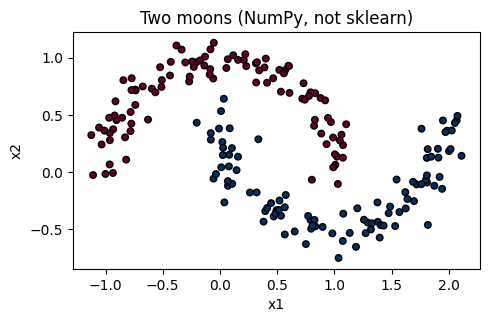

In [16]:
def make_two_moons(n=200, noise=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n2 = n // 2
    t = np.linspace(0, np.pi, n2)
    moon0 = np.stack([np.cos(t), np.sin(t)], axis=1)                    # first arc
    moon1 = np.stack([1 - np.cos(t), 1 - np.sin(t) - 0.5], axis=1)      # second arc, shifted to interlock
    X = np.concatenate([moon0, moon1], axis=0)
    X = X + rng.normal(0, noise, X.shape)   # add a bit of noise so it's not a perfect curve
    y = np.concatenate([np.zeros((n2, 1)), np.ones((n2, 1))])  # label each arc 0 or 1
    idx = rng.permutation(n)   # shuffle so the two classes aren't stacked in blocks
    return X[idx], y[idx]


X, y = make_two_moons()
print("X", X.shape, "y", y.shape, "class counts", int((y == 0).sum()), int((y == 1).sum()))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="RdBu", edgecolor="k", s=22)
ax.set_title("Two moons (NumPy, not sklearn)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

200 points, 100 per class, in two interlocking arcs. No straight line separates these cleanly.

Wrapping `train_step` in a loop, one call per epoch, tracking the loss each time.

In [17]:
def train(X, y, n_hidden=8, lr=1.0, epochs=400, use_relu=True, seed=42, print_every=50):
    W1, b1, W2, b2 = init_params(n_hidden=n_hidden, seed=seed)
    losses = []
    for epoch in range(1, epochs + 1):
        (W1, b1, W2, b2), loss_b, loss_a = train_step(
            X, y, W1, b1, W2, b2, lr=lr, use_relu=use_relu
        )
        losses.append(loss_a)
        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            print(f"epoch {epoch:4d}  loss {loss_a:.4f}")
    params = (W1, b1, W2, b2)
    return params, np.array(losses)


params, losses = train(X, y, epochs=400, lr=1.0, n_hidden=8, use_relu=True)
print("final loss", round(float(losses[-1]), 4))

epoch    1  loss 0.6160
epoch   50  loss 0.2353
epoch  100  loss 0.1923
epoch  150  loss 0.1267
epoch  200  loss 0.0771
epoch  250  loss 0.0514
epoch  300  loss 0.0378
epoch  350  loss 0.0298
epoch  400  loss 0.0248
final loss 0.0248


Loss starts near `0.616` and ends near `0.025` after 400 epochs — down, and by a lot. The plot below is that same sequence of numbers.

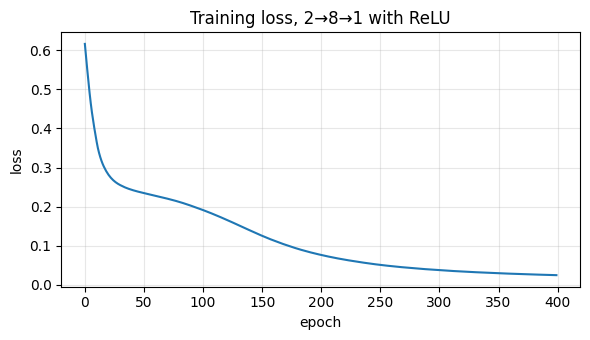

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(losses)   # loss at every epoch
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss, 2→8→1 with ReLU")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fast drop early, flattening out later — the weights found a good direction quickly, then made smaller and smaller corrections.

**Try it.** Compare `epochs=50` against `epochs=400` in `train(...)`. 50 will usually still be falling; 400 should be close to flat by the end.

---
## 12. Did it learn a curve?

A falling loss number doesn't prove the shape of what got learned. Checking with actual probabilities first, on 8 real points from the dataset.

In [19]:
W1, b1, W2, b2 = params
A2, _ = forward(X, W1, b1, W2, b2, use_relu=True)
pred = (A2 >= 0.5).astype(int)   # threshold the probability into a 0/1 class
print("first 8 probabilities:", np.round(A2[:8].ravel(), 3))
print("first 8 predicted cls:", pred[:8].ravel())
print("first 8 true labels:  ", y[:8].ravel().astype(int))
print("accuracy:             ", round(float((pred == y).mean()), 3))

first 8 probabilities: [0.001 0.001 0.998 0.998 0.001 0.981 0.99  0.003]
first 8 predicted cls: [0 0 1 1 0 1 1 0]
first 8 true labels:   [0 0 1 1 0 1 1 0]
accuracy:              0.995


Probabilities land near the extremes — `0.001`, `0.998`, `0.981`, and so on — not near `0.5`. Every one of the 8 predicted classes matches the true label, and accuracy across all 200 points comes out to `0.995`.

The plot below computes this same probability at thousands of points, not just 8, and colors the plane by it.

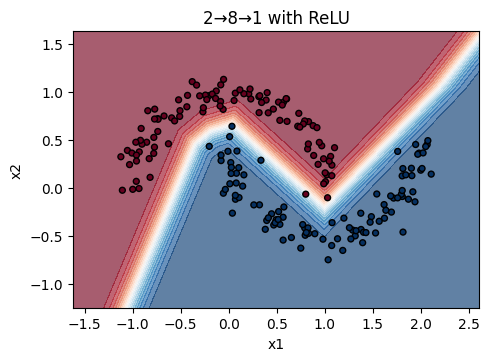

In [20]:
def plot_boundary(ax, params, X, y, use_relu, title):
    W1, b1, W2, b2 = params
    pad = 0.5
    # Build a grid of points covering the whole plot area
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 250),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 250),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Run the network's forward pass on every point in that grid
    probs = forward(grid, W1, b1, W2, b2, use_relu=use_relu)[0].reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.65, vmin=0, vmax=1)  # color by probability
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="RdBu", edgecolor="k", s=18, vmin=0, vmax=1)  # overlay real points
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal")


fig, ax = plt.subplots(figsize=(5, 4))
plot_boundary(ax, params, X, y, use_relu=True, title="2→8→1 with ReLU")
plt.tight_layout()
plt.show()

The colored regions bend around each arc instead of slicing through with one straight edge — a shape a linear model can't produce.

Same architecture, no bend this time: the hidden layer becomes a plain `Z1` with nothing applied to it. Retraining from scratch, then plotting both boundaries side by side.

epoch    1  loss 0.5384
epoch   50  loss 0.2653
epoch  100  loss 0.2651
epoch  150  loss 0.2651
epoch  200  loss 0.2651
epoch  250  loss 0.2651
epoch  300  loss 0.2651
epoch  350  loss 0.2651
epoch  400  loss 0.2651
no-ReLU accuracy 0.885
ReLU accuracy    0.995


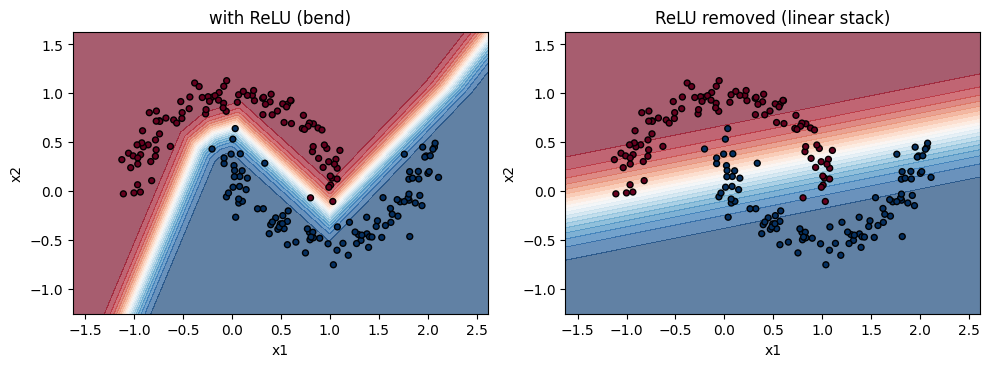

In [21]:
params_lin, losses_lin = train(X, y, epochs=400, lr=1.0, n_hidden=8, use_relu=False)   # same net, bend removed
A2_lin, _ = forward(X, *params_lin, use_relu=False)
print("no-ReLU accuracy", round(float(((A2_lin >= 0.5).astype(int) == y).mean()), 3))
print("ReLU accuracy   ", round(float((pred == y).mean()), 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_boundary(axes[0], params, X, y, use_relu=True, title="with ReLU (bend)")
plot_boundary(axes[1], params_lin, X, y, use_relu=False, title="ReLU removed (linear stack)")
plt.tight_layout()
plt.show()

With ReLU: `99.5%` accuracy, boundary curves with the moons. Without ReLU: `88.5%` accuracy, boundary close to a straight line. Same architecture, same data, same training loop — the only difference is one bend, and that's what's separating the two pictures.

That answers the Section 2 question directly: strip the bend out, and stacking more of the same linear pieces doesn't buy you a curve, no matter how many layers deep it goes.

**Try it.** Retrain the ReLU version with `n_hidden=1` — that's next.

---
## 13. What can go wrong

Two quick experiments: a learning rate that's too big, and a hidden layer too small to do the job.

High learning rate (lr=15), 80 epochs
epoch    1  loss 0.5455
epoch   20  loss 0.4429
epoch   40  loss 0.4335
epoch   60  loss 0.4328
epoch   80  loss 0.4239

Hidden size 1, lr=1.0, 400 epochs
epoch    1  loss 0.6573
epoch  100  loss 0.2725
epoch  200  loss 0.2674
epoch  300  loss 0.2662
epoch  400  loss 0.2658


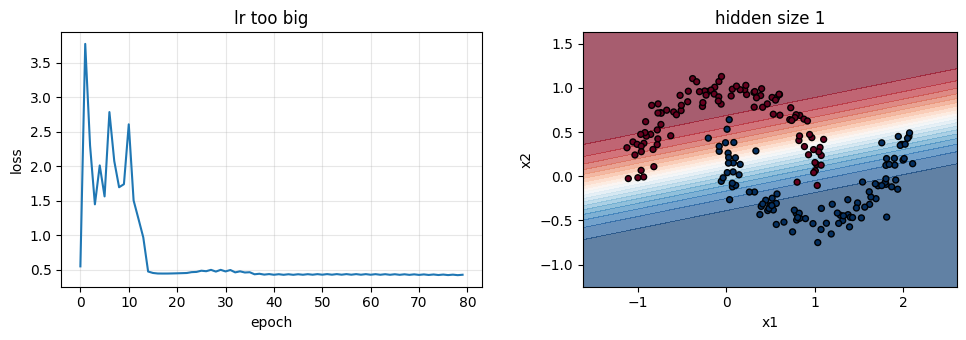

In [22]:
print("High learning rate (lr=15), 80 epochs")
_, losses_hi = train(X, y, epochs=80, lr=15.0, n_hidden=8, print_every=20)   # step size way too big
print()
print("Hidden size 1, lr=1.0, 400 epochs")
params_tiny, losses_tiny = train(X, y, epochs=400, lr=1.0, n_hidden=1, print_every=100)   # only one neuron to bend with

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(losses_hi)
axes[0].set_title("lr too big")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)
plot_boundary(axes[1], params_tiny, X, y, use_relu=True, title="hidden size 1")
plt.tight_layout()
plt.show()

With `lr=15`, loss spikes as high as `3.77` before settling near `0.42` — nowhere near the smooth drop from `lr=1.0`. A jumpy loss isn't faster learning, it's overshooting the target on every step.

With `n_hidden=1`, final loss is `0.266` and accuracy lands at `0.885` — close to the no-ReLU run, not the 8-neuron one. One hidden neuron gives you roughly one hinge, and that's not enough to wrap around two moons.

---
## 14. The same net in PyTorch

What we just wrote by hand — forward, loss, backward, update — is the same sequence Part 4 wrote as `pred → loss → zero_grad → backward → step`. The cell below builds the identical 2→8→1 net in PyTorch.

In [23]:
import torch
import torch.nn as nn

Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y, dtype=torch.float32)

# Same shape as W1/b1/W2/b2 above, just built with PyTorch's layer classes
model_t = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
opt = torch.optim.SGD(model_t.parameters(), lr=0.5)
loss_fn = nn.BCELoss()   # same "confident and wrong costs more" loss as our bce() function

for epoch in range(400):
    pred = model_t(Xt)            # forward pass
    loss = loss_fn(pred, yt)      # loss
    opt.zero_grad()               # clear blame from the last step
    loss.backward()               # backprop — autograd works out the gradients for us
    opt.step()                    # W ← W - lr * dW, same update rule as before
    if epoch == 0 or (epoch + 1) % 100 == 0:
        print(f"epoch {epoch+1:4d}  loss {loss.item():.4f}")

epoch    1  loss 0.7360
epoch  100  loss 0.2616
epoch  200  loss 0.2281
epoch  300  loss 0.1698
epoch  400  loss 0.1003


The loop is the same one from Section 10: predict, score, adjust. The difference is that PyTorch works out the gradients for you instead of you writing `backward()` by hand. Part 7 builds on this to train in a more realistic setup — batches, a better optimizer, real image data.

---
## 15. Recap

### What you now know

- a neuron is a linear score plus a bend
- a layer is a bunch of neurons
- an MLP is layers chained together
- forward pass = prediction
- loss = how wrong that prediction was
- backprop = the chain rule, sending blame backward
- training = repeat that loop and take a step each time

The loop, still:

```text
Data → Model → Prediction → Loss → Optimization → Evaluation → Generalization
```

### How it connects

- linear algebra gave you `Wx + b`
- calculus gave you "move against the gradient"
- Part 5 gave you the loop
- this notebook gave you that same loop, inside a network you built yourself

### Next: Part 7 — Training Neural Networks for Real

Same kind of network, a real training setup this time: batches, Adam, one regularizer, Fashion-MNIST, and train/val curves. Still no CNNs or transformers.